# Tarea 03: Diseño de experimentos para clasificación de textos
## Autor: Alejandra Paola Castillo Gallegos

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
import warnings

warnings.filterwarnings("ignore")

# Herramientas de Scikit-Learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Para descargar archivos en Google Colab
from google.colab import files

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# 2. CARGA DEL CONJUNTO DE DATOS

url = (
    "https://raw.githubusercontent.com/"
    "mohitgupta-omg/"
    "Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
)

df = pd.read_csv(
    url,
    encoding="latin-1"
)

# Eliminamos columnas innecesarias
df.drop(
    ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],
    axis=1,
    inplace=True
)

# Renombramos las columnas
df.columns = ["label", "text"]

print("Dimensiones del dataset:")
print(df.shape)

display(df.head())

Dimensiones del dataset:
(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# 2. CARGA DEL CONJUNTO DE DATOS

url = (
    "https://raw.githubusercontent.com/"
    "mohitgupta-omg/"
    "Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
)

df = pd.read_csv(
    url,
    encoding="latin-1"
)

# Eliminamos columnas innecesarias
df.drop(
    ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],
    axis=1,
    inplace=True
)

# Renombramos las columnas
df.columns = ["label", "text"]

print("Dimensiones del dataset:")
print(df.shape)

display(df.head())

Dimensiones del dataset:
(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


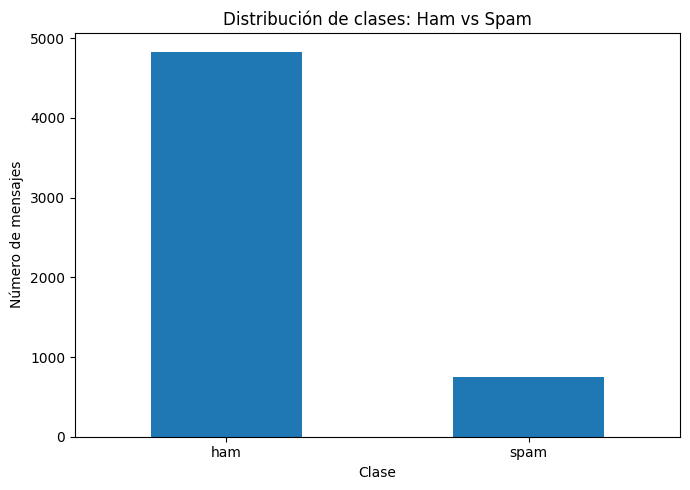

In [4]:
# Distribución de las clases

plt.figure(figsize=(7, 5))

df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribución de clases: Ham vs Spam"
)

plt.xlabel("Clase")
plt.ylabel("Número de mensajes")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "distribucion_clases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# 4. PREPROCESAMIENTO DEL TEXTO

def limpiar_texto(texto):

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(
        r"http\S+|www\S+",
        " ",
        texto
    )

    # Eliminar correos electrónicos
    texto = re.sub(
        r"\S+@\S+",
        " ",
        texto
    )

    # Mantener únicamente letras y espacios
    texto = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        texto
    )

    # Eliminar espacios repetidos
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto


df["text_clean"] = (
    df["text"]
    .astype(str)
    .apply(limpiar_texto)
)

display(
    df[
        ["text", "text_clean", "label"]
    ].head()
)

,text,text_clean,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,ham


In [6]:
# 4. PREPROCESAMIENTO DEL TEXTO

def limpiar_texto(texto):

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(
        r"http\S+|www\S+",
        " ",
        texto
    )

    # Eliminar correos electrónicos
    texto = re.sub(
        r"\S+@\S+",
        " ",
        texto
    )

    # Mantener únicamente letras y espacios
    texto = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        texto
    )

    # Eliminar espacios repetidos
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto


df["text_clean"] = (
    df["text"]
    .astype(str)
    .apply(limpiar_texto)
)

display(
    df[
        ["text", "text_clean", "label"]
    ].head()
)

,text,text_clean,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,ham


In [7]:
# 6. DIVISIÓN TRAIN / TEST

X = df["text_clean"]

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Entrenamiento:",
    len(X_train)
)

print(
    "Prueba:",
    len(X_test)
)

print("\nDistribución entrenamiento:")

print(
    y_train.value_counts(
        normalize=True
    )
)

print("\nDistribución prueba:")

print(
    y_test.value_counts(
        normalize=True
    )
)

Entrenamiento: 4457
Prueba: 1115

Distribución entrenamiento:
label
ham     0.865829
spam    0.134171
Name: proportion, dtype: float64

Distribución prueba:
label
ham     0.866368
spam    0.133632
Name: proportion, dtype: float64


In [8]:
# 7. CONFIGURACIÓN DEL DISEÑO EXPERIMENTAL

experimentos = []


# ------------------------------------------------------------
# Experimento 1
# CountVectorizer + Logistic Regression
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "CountVectorizer + LogisticRegression",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                CountVectorizer()
            ),

            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "classifier__C":
            [0.1, 1, 10]

    }

})


# ------------------------------------------------------------
# Experimento 2
# TF-IDF + Logistic Regression
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "TFIDF + LogisticRegression",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                TfidfVectorizer()
            ),

            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "vectorizer__max_features":
            [None, 5000],

        "classifier__C":
            [0.1, 1, 10]

    }

})


# ------------------------------------------------------------
# Experimento 3
# CountVectorizer + Naive Bayes
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "CountVectorizer + MultinomialNB",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                CountVectorizer()
            ),

            (
                "classifier",
                MultinomialNB()
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "classifier__alpha":
            [0.1, 0.5, 1.0]

    }

})


# ------------------------------------------------------------
# Experimento 4
# TF-IDF + Naive Bayes
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "TFIDF + MultinomialNB",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                TfidfVectorizer()
            ),

            (
                "classifier",
                MultinomialNB()
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "classifier__alpha":
            [0.1, 0.5, 1.0]

    }

})


# ------------------------------------------------------------
# Experimento 5
# CountVectorizer + Linear SVM
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "CountVectorizer + LinearSVC",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                CountVectorizer()
            ),

            (
                "classifier",
                LinearSVC(
                    random_state=42
                )
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "classifier__C":
            [0.1, 1, 10]

    }

})


# ------------------------------------------------------------
# Experimento 6
# TF-IDF + Linear SVM
# ------------------------------------------------------------

experimentos.append({

    "nombre":
        "TFIDF + LinearSVC",

    "pipeline":
        Pipeline([

            (
                "vectorizer",
                TfidfVectorizer()
            ),

            (
                "classifier",
                LinearSVC(
                    random_state=42
                )
            )

        ]),

    "params": {

        "vectorizer__ngram_range":
            [(1, 1), (1, 2)],

        "vectorizer__min_df":
            [1, 2],

        "vectorizer__max_features":
            [None, 5000],

        "classifier__C":
            [0.1, 1, 10]

    }

})


print(
    "Número de familias experimentales:",
    len(experimentos)
)

Número de familias experimentales: 6


In [9]:
# 8. CONFIGURACIÓN DE VALIDACIÓN CRUZADA

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [10]:
# 9. EJECUCIÓN DE LOS EXPERIMENTOS

resultados = []

mejores_modelos = {}

for experimento in experimentos:

    print(
        "\n" +
        "=" * 80
    )

    print(
        "Ejecutando:",
        experimento["nombre"]
    )

    print(
        "=" * 80
    )

    inicio = time.time()

    grid = GridSearchCV(

        estimator=
            experimento["pipeline"],

        param_grid=
            experimento["params"],

        scoring="f1_macro",

        cv=cv,

        n_jobs=-1,

        verbose=0

    )

    # Entrenamiento
    grid.fit(
        X_train,
        y_train
    )

    tiempo = (
        time.time()
        -
        inicio
    )

    # Mejor modelo
    mejor_modelo = (
        grid.best_estimator_
    )

    mejores_modelos[
        experimento["nombre"]
    ] = mejor_modelo

    # Predicción
    y_pred = (
        mejor_modelo.predict(
            X_test
        )
    )

    # Métricas
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    resultados.append({

        "Experimento":
            experimento["nombre"],

        "Mejores hiperparametros":
            str(
                grid.best_params_
            ),

        "CV_F1_macro":
            grid.best_score_,

        "Accuracy":
            accuracy,

        "Precision_spam":
            precision,

        "Recall_spam":
            recall,

        "F1_spam":
            f1,

        "Tiempo_seg":
            tiempo

    })

    print(
        "Mejores parámetros:"
    )

    print(
        grid.best_params_
    )

    print(
        "\nF1 macro CV:",
        round(
            grid.best_score_,
            4
        )
    )

    print(
        "Accuracy:",
        round(
            accuracy,
            4
        )
    )

    print(
        "Precision Spam:",
        round(
            precision,
            4
        )
    )

    print(
        "Recall Spam:",
        round(
            recall,
            4
        )
    )

    print(
        "F1 Spam:",
        round(
            f1,
            4
        )
    )

    print(
        "Tiempo:",
        round(
            tiempo,
            2
        ),
        "segundos"
    )


Ejecutando: CountVectorizer + LogisticRegression
Mejores parámetros:
{'classifier__C': 10, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}

F1 macro CV: 0.959
Accuracy: 0.9812
Precision Spam: 0.9923
Recall Spam: 0.8658
F1 Spam: 0.9247
Tiempo: 20.31 segundos

Ejecutando: TFIDF + LogisticRegression
Mejores parámetros:
{'classifier__C': 10, 'vectorizer__max_features': None, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}

F1 macro CV: 0.9639
Accuracy: 0.9848
Precision Spam: 0.9853
Recall Spam: 0.8993
F1 Spam: 0.9404
Tiempo: 20.57 segundos

Ejecutando: CountVectorizer + MultinomialNB
Mejores parámetros:
{'classifier__alpha': 0.5, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}

F1 macro CV: 0.969
Accuracy: 0.983
Precision Spam: 0.9577
Recall Spam: 0.9128
F1 Spam: 0.9347
Tiempo: 9.06 segundos

Ejecutando: TFIDF + MultinomialNB
Mejores parámetros:
{'classifier__alpha': 0.1, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}

F1 macro CV: 0.9699
A

In [11]:
# 10. TABLA GENERAL DE RESULTADOS

resultados_df = pd.DataFrame(
    resultados
)

resultados_df = (
    resultados_df
    .sort_values(
        by="F1_spam",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultados_df
)

,Experimento,Mejores hiperparametros,CV_F1_macro,Accuracy,Precision_spam,Recall_spam,F1_spam,Tiempo_seg
0,TFIDF + LinearSVC,"{'classifier__C': 1, 'vectorizer__max_features...",0.967416,0.986547,0.985507,0.912752,0.947735,19.292876
1,TFIDF + LogisticRegression,"{'classifier__C': 10, 'vectorizer__max_feature...",0.963867,0.984753,0.985294,0.899329,0.940351,20.572140
2,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.5, 'vectorizer__min_df...",0.969038,0.982960,0.957746,0.912752,0.934708,9.059112
3,TFIDF + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.969908,0.982960,0.992424,0.879195,0.932384,9.174581
4,CountVectorizer + LogisticRegression,"{'classifier__C': 10, 'vectorizer__min_df': 2,...",0.959041,0.981166,0.992308,0.865772,0.924731,20.306471
5,CountVectorizer + LinearSVC,"{'classifier__C': 10, 'vectorizer__min_df': 2,...",0.964239,0.980269,0.963504,0.885906,0.923077,10.537307


In [12]:
# 11. EXPORTACIÓN DE RESULTADOS

resultados_df.to_csv(
    "resultados_experimentos.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Archivo resultados_experimentos.csv generado."
)

Archivo resultados_experimentos.csv generado.


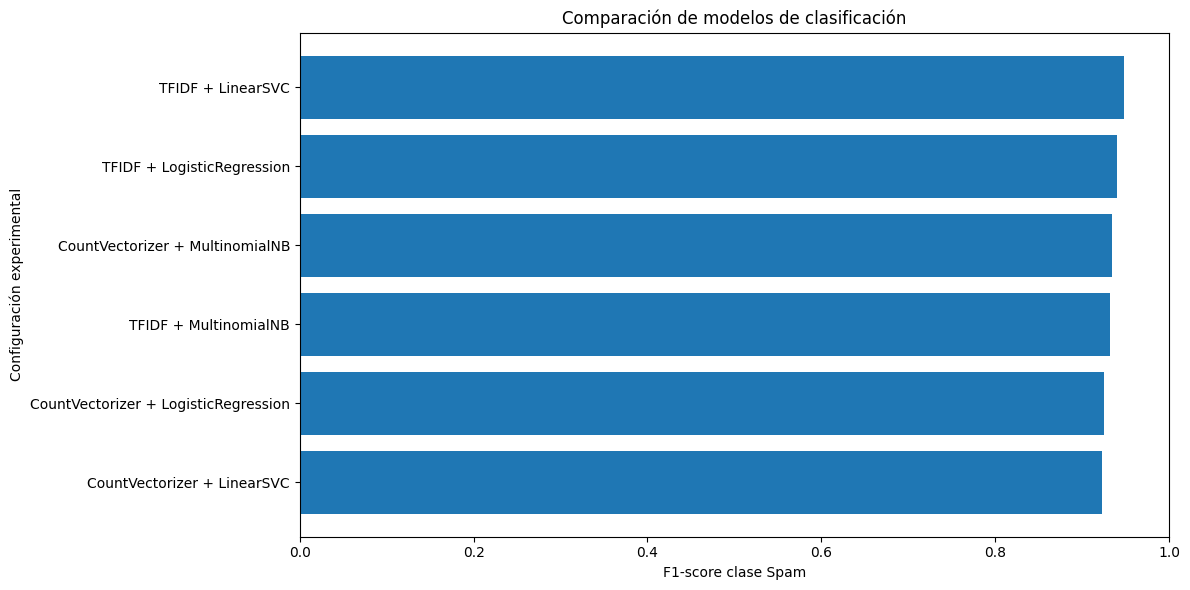

In [13]:
# 12. COMPARACIÓN DEL DESEMPEÑO

plt.figure(
    figsize=(12, 6)
)

plt.barh(
    resultados_df[
        "Experimento"
    ],
    resultados_df[
        "F1_spam"
    ]
)

plt.xlabel(
    "F1-score clase Spam"
)

plt.ylabel(
    "Configuración experimental"
)

plt.title(
    "Comparación de modelos de clasificación"
)

plt.xlim(
    0,
    1
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "comparacion_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

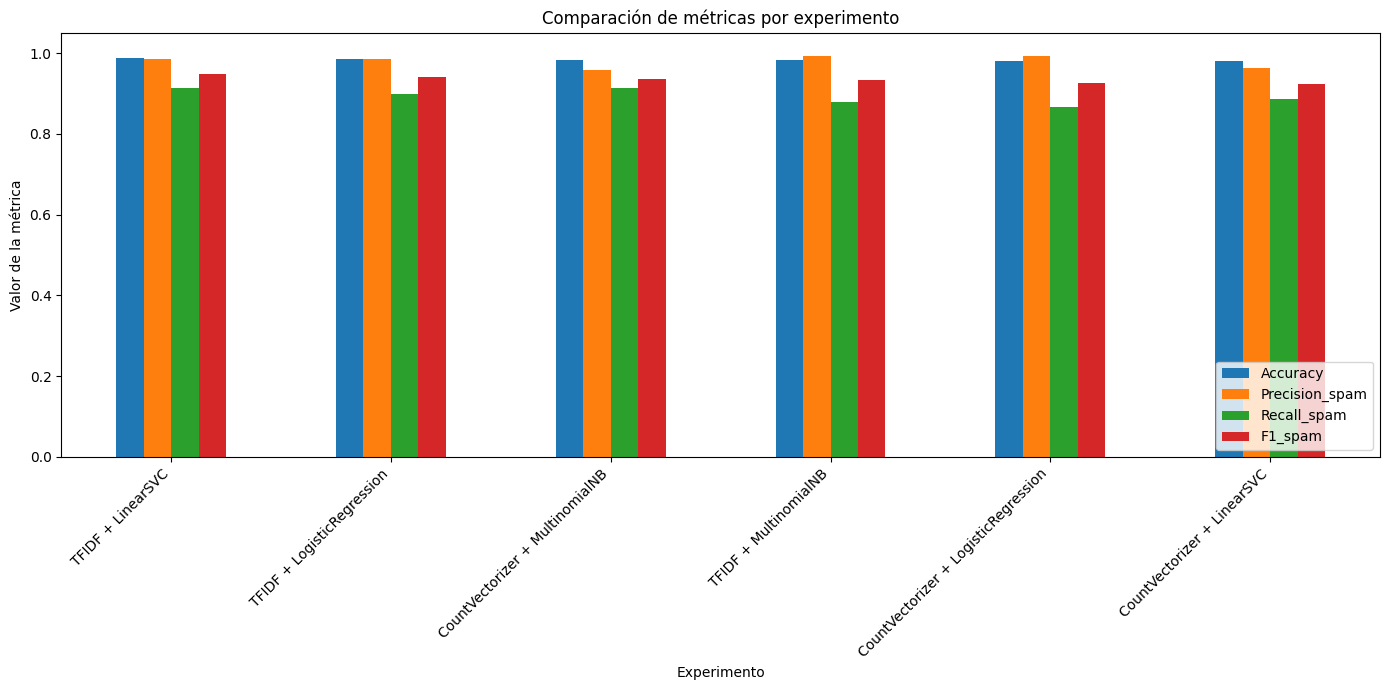

In [14]:
metricas = (

    resultados_df[

        [
            "Experimento",
            "Accuracy",
            "Precision_spam",
            "Recall_spam",
            "F1_spam"
        ]

    ]

    .set_index(
        "Experimento"
    )

)

metricas.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Comparación de métricas por experimento"
)

plt.ylabel(
    "Valor de la métrica"
)

plt.xlabel(
    "Experimento"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "metricas_experimentos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# 13. SELECCIÓN DEL MEJOR MODELO

mejor_nombre = (
    resultados_df
    .iloc[0][
        "Experimento"
    ]
)

mejor_modelo = (
    mejores_modelos[
        mejor_nombre
    ]
)

print(
    "Mejor configuración:"
)

print(
    mejor_nombre
)

Mejor configuración:
TFIDF + LinearSVC


In [16]:
# Predicciones del mejor modelo

y_pred_final = (
    mejor_modelo.predict(
        X_test
    )
)

print(
    classification_report(
        y_test,
        y_pred_final,
        digits=4
    )
)

              precision    recall  f1-score   support

         ham     0.9867    0.9979    0.9923       966
        spam     0.9855    0.9128    0.9477       149

    accuracy                         0.9865      1115
   macro avg     0.9861    0.9553    0.9700      1115
weighted avg     0.9865    0.9865    0.9863      1115



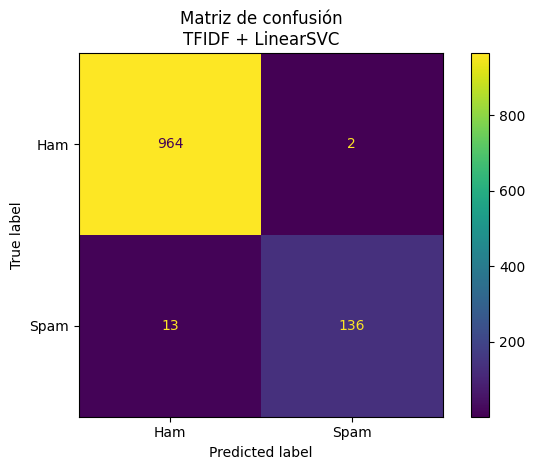

In [17]:
# 14. MATRIZ DE CONFUSIÓN

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[
        "ham",
        "spam"
    ]
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Ham",
        "Spam"
    ]

)

disp.plot(
    values_format="d"
)

plt.title(
    f"Matriz de confusión\n{mejor_nombre}"
)

plt.tight_layout()

plt.savefig(
    "matriz_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# 15. RESULTADOS DETALLADOS DE GRID SEARCH

resultados_grid = []

for experimento in experimentos:

    grid = GridSearchCV(

        estimator=
            experimento["pipeline"],

        param_grid=
            experimento["params"],

        scoring="f1_macro",

        cv=cv,

        n_jobs=-1

    )

    grid.fit(
        X_train,
        y_train
    )

    temp = pd.DataFrame(
        grid.cv_results_
    )

    temp[
        "Experimento"
    ] = experimento[
        "nombre"
    ]

    resultados_grid.append(
        temp
    )


grid_completo = pd.concat(
    resultados_grid,
    ignore_index=True
)

columnas = [

    "Experimento",
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"

]

display(
    grid_completo[
        columnas
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
    .head(20)
)

,Experimento,params,mean_test_score,std_test_score,rank_test_score
49,TFIDF + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.969908,0.005270,1
41,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.5, 'vectorizer__min_df...",0.969038,0.004280,1
37,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.967973,0.007293,2
51,TFIDF + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.967904,0.002950,2
38,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.967468,0.004639,3
83,TFIDF + LinearSVC,"{'classifier__C': 1, 'vectorizer__max_features...",0.967416,0.003336,1
47,CountVectorizer + MultinomialNB,"{'classifier__alpha': 1.0, 'vectorizer__min_df...",0.967410,0.005121,4
89,TFIDF + LinearSVC,"{'classifier__C': 10, 'vectorizer__max_feature...",0.967376,0.003044,2
39,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.1, 'vectorizer__min_df...",0.967275,0.005182,5
40,CountVectorizer + MultinomialNB,"{'classifier__alpha': 0.5, 'vectorizer__min_df...",0.966961,0.003465,6


In [19]:
grid_completo.to_csv(
    "resultados_gridsearch_completos.csv",
    index=False,
    encoding="utf-8-sig"
)

In [20]:
# 16. PRUEBA CON MENSAJES NUEVOS

mensajes_nuevos = [

    "Congratulations! You have won a free prize. Call now to claim.",

    "Hi, are we still meeting tomorrow at 10?",

    "URGENT! You have won $1000. Click here to receive your reward.",

    "Can you please send me the homework when you finish?"

]

mensajes_limpios = [

    limpiar_texto(
        mensaje
    )

    for mensaje
    in mensajes_nuevos

]

predicciones = (
    mejor_modelo.predict(
        mensajes_limpios
    )
)

resultado_prueba = pd.DataFrame({

    "Mensaje":
        mensajes_nuevos,

    "Prediccion":
        predicciones

})

display(
    resultado_prueba
)

,Mensaje,Prediccion
0,Congratulations! You have won a free prize. Ca...,spam
1,"Hi, are we still meeting tomorrow at 10?",ham
2,URGENT! You have won $1000. Click here to rece...,spam
3,Can you please send me the homework when you f...,ham


In [21]:
# 17. RESUMEN FINAL

mejor = (
    resultados_df.iloc[0]
)

print(
    "RESUMEN DEL EXPERIMENTO"
)

print(
    "-" * 60
)

print(
    f"Mejor modelo: "
    f"{mejor['Experimento']}"
)

print(
    f"Accuracy: "
    f"{mejor['Accuracy']:.4f}"
)

print(
    f"Precision Spam: "
    f"{mejor['Precision_spam']:.4f}"
)

print(
    f"Recall Spam: "
    f"{mejor['Recall_spam']:.4f}"
)

print(
    f"F1 Spam: "
    f"{mejor['F1_spam']:.4f}"
)

print(
    f"CV F1 Macro: "
    f"{mejor['CV_F1_macro']:.4f}"
)

print(
    "\nMejores hiperparámetros:"
)

print(
    mejor[
        "Mejores hiperparametros"
    ]
)

RESUMEN DEL EXPERIMENTO
------------------------------------------------------------
Mejor modelo: TFIDF + LinearSVC
Accuracy: 0.9865
Precision Spam: 0.9855
Recall Spam: 0.9128
F1 Spam: 0.9477
CV F1 Macro: 0.9674

Mejores hiperparámetros:
{'classifier__C': 1, 'vectorizer__max_features': None, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}


In [ ]:
files.download("resultados_experimentos.csv")
files.download("resultados_gridsearch_completos.csv")